# Standard GD Training for Modular Addition (Shared Embedding)

Training with **standard gradient descent** (no spherical projection) with scale parameters fixed.

**Key difference from spherical training:** Weights do NOT stay on the unit sphere.

For `share_embed=True`, embeddings are summed: $e_x + e_y$, appropriate for commutative operations like addition.

In [18]:
import sys
sys.path.insert(0, '..')

import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from src import Config, SphericalTrainer, get_task, get_basis

# Font settings - use Palatino, no LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'P052', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

## 1. Configuration (Standard GD, Shared Embedding)

In [19]:
config = Config(
    # Task
    task_name='modular_addition',
    p=23,           # 1-d case: Z_17
    # n=[2,3,5],     # d-dim case (uncomment to use)
    
    # Model - SHARED EMBEDDING
    width=128,
    act_type='Quad',
    init_scale=2.0,
    share_embed=True,  # Sum embeddings e_x + e_y (commutative)
    
    # Stage 1: Will use standard GD instead
    stage1_enabled=True,
    stage1_lr=0.1,
    stage1_num_epochs=30000,
    stage1_optimizer='Adam',
    stage1_freeze_scales=True,
    
    # Stage 2: Disabled
    stage2_enabled=False,
    
    # Logging
    print_every=1000,
    track_phases=False,
    track_scales=True,
    
    # System
    seed=42,
)

print(f"Device: {config.device}")
print(f"Task: {config.task_name}")
print(f"Moduli: {config.moduli} (vocab_size={config.d_vocab})")
print(f"Model: width={config.width}, activation={config.act_type}")
print(f"share_embed={config.share_embed} -> W_in shape will be (width, vocab_size)")

Device: auto
Task: modular_addition
Moduli: [23] (vocab_size=23)
Model: width=128, activation=Quad
share_embed=True -> W_in shape will be (width, vocab_size)


## 2. Initialize Model

In [20]:
trainer = SphericalTrainer(config)

print(f"\nModel architecture:")
print(f"  W_in:  {trainer.model.W_in.shape}  <- (width, vocab_size) for shared")
print(f"  W_out: {trainer.model.W_out.shape}")
print(f"  scale_in:  {trainer.model.scale_in.item():.4f}")
print(f"  scale_out: {trainer.model.scale_out.item():.4f}")

print(f"\nBasis: {trainer.basis}")
print(f"Dataset: {len(trainer.data)} samples")

Initialized SphericalTrainer:
  Task: ModularAddition(n=23)
  Basis: FourierBasis(n=23)
  Device: cpu
  Data size: 529
  Model:
WideNetworkScaleSphere(
  d_vocab=23,
  width=128,
  act_type='Quad',
  share_embed=True,
  d_input=23,
  scale_in=2.0000,
  scale_out=2.0000
)

Model architecture:
  W_in:  torch.Size([128, 23])  <- (width, vocab_size) for shared
  W_out: torch.Size([23, 128])
  scale_in:  2.0000
  scale_out: 2.0000

Basis: FourierBasis(n=23)
Dataset: 529 samples


## 3. Run Training (Standard GD, Fixed Scale)

Standard gradient descent **without** projection to tangent space or normalization.

In [21]:
# Save initial weights before training
W_in_init = trainer.model.W_in.detach().cpu().clone()
W_out_init = trainer.model.W_out.detach().cpu().clone()

# Manual standard GD training (not using trainer.train())
model = trainer.model
basis = trainer.basis
vocab_size = config.d_vocab

# Freeze scales
model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

# Optimizer - standard Adam, no spherical projection
optimizer = optim.SGD([model.W_in, model.W_out], lr=config.stage1_lr)

# Generate data
data, labels = trainer.task.generate_all_data(config.torch_device)

# Training history
losses = []
accuracies = []

# Norm tracking (unique to standard GD)
norm_history_theta = []
norm_history_xi = []

def compute_weight_norms():
    W_in = model.W_in.detach().cpu()
    W_out = model.W_out.detach().cpu()
    return (W_in.norm(dim=1).mean().item(),
            W_out.norm(dim=0).mean().item())

def cross_entropy_high_precision(logits, labels):
    log_probs = torch.log_softmax(logits.double(), dim=-1)
    return -log_probs[torch.arange(len(labels)), labels].mean().float()

def accuracy(logits, labels):
    return (logits.argmax(dim=-1) == labels).float().mean().item()

print("=" * 60)
print("Standard GD Training (Scale fixed, NO spherical projection)")
print("=" * 60)
print(f"Fixed scale_in = {model.scale_in.item():.4f}, scale_out = {model.scale_out.item():.4f}")
print(f"share_embed = {config.share_embed}")

n_theta, n_xi = compute_weight_norms()
print(f"Initial avg norms: θ={n_theta:.4f}, ξ={n_xi:.4f}")

NUM_EPOCHS = config.stage1_num_epochs
TRACK_EVERY = 10

for epoch in range(NUM_EPOCHS):
    if epoch % TRACK_EVERY == 0:
        n_theta, n_xi = compute_weight_norms()
        norm_history_theta.append(n_theta)
        norm_history_xi.append(n_xi)
    
    optimizer.zero_grad()
    
    # Forward
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc = accuracy(logits, labels)
    
    # Backward
    loss.backward()
    
    # Standard GD step (NO projection, NO normalization)
    optimizer.step()
    
    losses.append(loss.item())
    accuracies.append(acc)
    
    if epoch % config.print_every == 0:
        n_theta, n_xi = compute_weight_norms()
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f} | "
              f"Norms: θ={n_theta:.3f}, ξ={n_xi:.3f}")

# Final
n_theta, n_xi = compute_weight_norms()
norm_history_theta.append(n_theta)
norm_history_xi.append(n_xi)

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")
print(f"Final avg norms: θ={n_theta:.4f}, ξ={n_xi:.4f}")
print(f"\n*** Weights have {'LEFT' if abs(n_theta-1) > 0.01 or abs(n_xi-1) > 0.01 else 'stayed on'} the unit sphere ***")

# For compatibility with later cells
stage1_history = {'loss': losses, 'accuracy': accuracies}
stage2_history = None

Standard GD Training (Scale fixed, NO spherical projection)
Fixed scale_in = 2.0000, scale_out = 2.0000
share_embed = True
Initial avg norms: θ=1.0000, ξ=1.0000
Epoch     0 | Loss: 3.134611 | Acc: 0.0491 | Norms: θ=1.000, ξ=1.000
Epoch  1000 | Loss: 3.130680 | Acc: 0.0756 | Norms: θ=1.004, ξ=1.002
Epoch  2000 | Loss: 3.126566 | Acc: 0.1078 | Norms: θ=1.014, ξ=1.007
Epoch  3000 | Loss: 3.122087 | Acc: 0.1304 | Norms: θ=1.030, ξ=1.015
Epoch  4000 | Loss: 3.117017 | Acc: 0.1815 | Norms: θ=1.053, ξ=1.027
Epoch  5000 | Loss: 3.111055 | Acc: 0.2212 | Norms: θ=1.083, ξ=1.043
Epoch  6000 | Loss: 3.103760 | Acc: 0.2609 | Norms: θ=1.121, ξ=1.063
Epoch  7000 | Loss: 3.094450 | Acc: 0.3157 | Norms: θ=1.167, ξ=1.088
Epoch  8000 | Loss: 3.081970 | Acc: 0.3932 | Norms: θ=1.225, ξ=1.120
Epoch  9000 | Loss: 3.064179 | Acc: 0.4612 | Norms: θ=1.296, ξ=1.160
Epoch 10000 | Loss: 3.036537 | Acc: 0.5198 | Norms: θ=1.384, ξ=1.211
Epoch 11000 | Loss: 2.987640 | Acc: 0.5690 | Norms: θ=1.496, ξ=1.277
Epoch 12000

### 3.1 Weight Norm Evolution

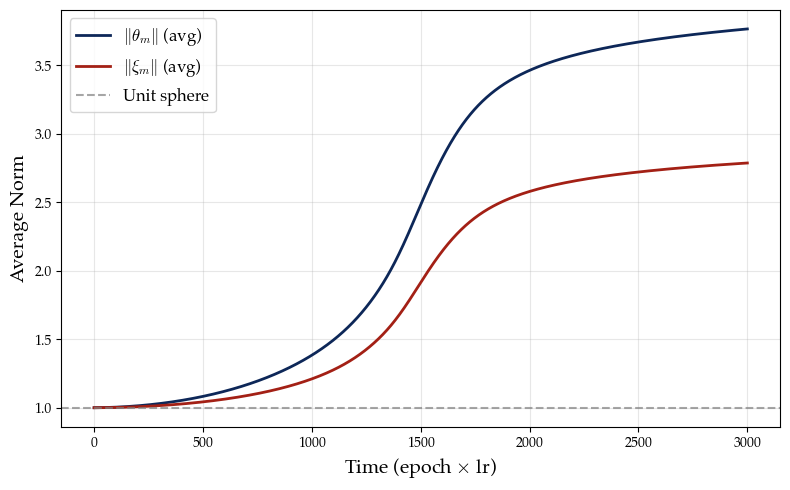

In [22]:
# Plot weight norm evolution
fig, ax = plt.subplots(figsize=(8, 5))

epochs_arr = np.arange(0, len(norm_history_theta)) * TRACK_EVERY
time_arr = epochs_arr * config.stage1_lr

ax.plot(time_arr, norm_history_theta, color='#0D2758', linewidth=2, label=r'$\|\theta_m\|$ (avg)')
ax.plot(time_arr, norm_history_xi, color='#A32015', linewidth=2, label=r'$\|\xi_m\|$ (avg)')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Unit sphere')
ax.set_xlabel(r'Time (epoch $\times$ lr)', fontsize=14)
ax.set_ylabel('Average Norm', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Single Frequency Phenomenon (Unnormalized DFT)

**Note:** DFT computed on raw (unnormalized) weights to see true energy distribution.

In [23]:
# Compute Fourier transform of weights (init and trained)
# Using paper's L²(G) DFT convention: ν̂[k] = (1/|G|) Σ_x ν(x) χ_k(x^{-1})

# Get trained weights
W_in = trainer.model.W_in.detach().cpu()
W_out = trainer.model.W_out.detach().cpu()

print(f"W_in shape: {W_in.shape}  <- (width, vocab_size) for shared embedding")
print(f"W_out shape: {W_out.shape}")

# NO normalization - use raw weights (standard GD)
# Apply Fourier transform with paper's L²(G) scaling
W_in_dft = basis.transform_paper(W_in)
W_out_dft = basis.transform_paper(W_out.T)

# Apply Fourier transform (initial)
W_in_init_dft = basis.transform_paper(W_in_init)
W_out_init_dft = basis.transform_paper(W_out_init.T)

print(f"\nWeight norms (trained):")
print(f"  θ avg norm: {W_in.norm(dim=1).mean():.4f}")
print(f"  ξ avg norm: {W_out.norm(dim=0).mean():.4f}")

# Get magnitudes (trained)
W_in_mag = torch.abs(W_in_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()

# Get magnitudes (initial)
W_in_init_mag = torch.abs(W_in_init_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"\nDFT shapes (paper notation ν̂[k] via basis.transform_paper()):")
print(f"W_in_dft: {W_in_dft.shape}")
print(f"W_out_dft: {W_out_dft.shape}")

W_in shape: torch.Size([128, 23])  <- (width, vocab_size) for shared embedding
W_out shape: torch.Size([23, 128])

Weight norms (trained):
  θ avg norm: 3.7665
  ξ avg norm: 2.7873

DFT shapes (paper notation ν̂[k] via basis.transform_paper()):
W_in_dft: torch.Size([128, 23])
W_out_dft: torch.Size([128, 23])


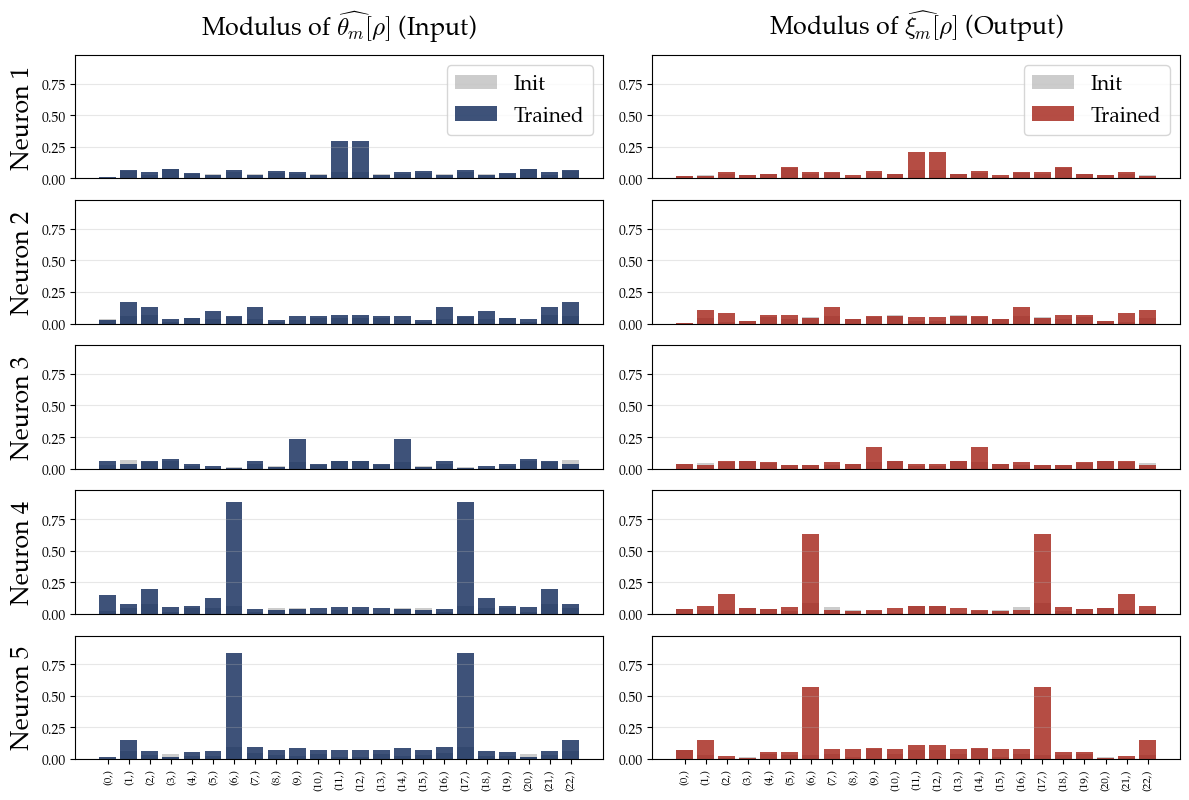

In [24]:
# Plot DFT comparison: Init (gray) vs Trained (color)
num_neurons_to_show = 5
freq_indices = np.arange(vocab_size)

# Get frequency tuples for x-axis labels
freq_labels = [str(basis.get_frequency_tuple(k)) for k in range(vocab_size)]

# Compute adaptive y-limit
max_val = 0
for m in range(num_neurons_to_show):
    max_val = max(max_val, 
                  W_in_mag[m].max(), W_out_mag[m].max(),
                  W_in_init_mag[m].max(), W_out_init_mag[m].max())
y_max = max_val * 1.1

fig, axes = plt.subplots(num_neurons_to_show, 2, figsize=(12, 1.8 * num_neurons_to_show))

for row in range(num_neurons_to_show):
    m = row
    is_last_row = (row == num_neurons_to_show - 1)
    
    # W_in (shared) - Blue
    ax = axes[row, 0]
    ax.bar(freq_indices, W_in_init_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_mag[m], alpha=0.8, color='#0D2758', label='Trained')
    ax.set_ylabel(f'Neuron {m+1}', fontsize=18)
    ax.set_ylim(0, y_max)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\theta_m}[\rho]$ (Input)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(freq_labels, fontsize=8, rotation=90)
    else:
        ax.set_xticks([])
    
    # W_out - Red
    ax = axes[row, 1]
    ax.bar(freq_indices, W_out_init_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_out_mag[m], alpha=0.8, color='#A32015', label='Trained')
    ax.set_ylim(0, y_max)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\xi_m}[\rho]$ (Output)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(freq_labels, fontsize=8, rotation=90)
    else:
        ax.set_xticks([])

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

Ordering: 11 non-self-conj + 1 self-conj + 11 conjugates
Self-conjugate frequencies: [(0,)]


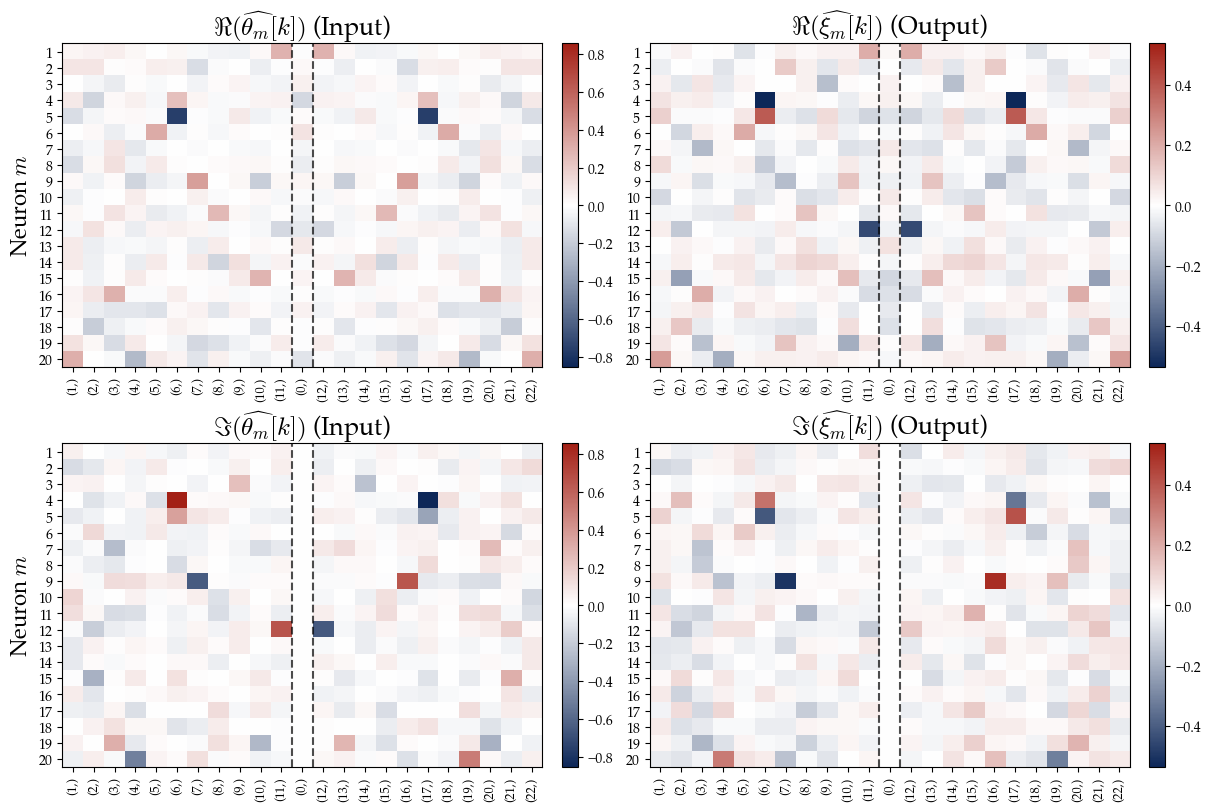

In [25]:
# Heatmap view: DFT coefficients for all neurons (2x2 grid)
# Top row: Real part, Bottom row: Imaginary part
# y-axis: neurons, x-axis: frequencies

from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: blue -> white -> red
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    ['#0D2758', 'white', '#A32015'],
    N=256
)

num_components = 20  # Number of neurons to show

# Create conjugate-symmetric ordering of frequencies
def get_conjugate(k_tuple, moduli):
    """Get the conjugate frequency tuple: -k mod n."""
    return tuple((-k) % n for k, n in zip(k_tuple, moduli))

def is_self_conjugate(k_tuple, moduli):
    """Check if k = -k mod n (self-conjugate)."""
    return k_tuple == get_conjugate(k_tuple, moduli)

# Build symmetric ordering
moduli = basis.n
all_tuples = [basis.get_frequency_tuple(k) for k in range(vocab_size)]

self_conj = []
left_half = []
right_half = []
seen = set()

for k_tuple in all_tuples:
    if k_tuple in seen:
        continue
    conj = get_conjugate(k_tuple, moduli)
    if is_self_conjugate(k_tuple, moduli):
        self_conj.append(k_tuple)
        seen.add(k_tuple)
    else:
        left_half.append(k_tuple)
        right_half.append(conj)
        seen.add(k_tuple)
        seen.add(conj)

# Final ordering: left + self_conj + right (reversed for symmetry)
symmetric_order = left_half + self_conj + right_half[::-1]
reorder_indices = [basis.tuple_to_index(t) for t in symmetric_order]

# Get frequency tuples for x-axis labels (reordered)
freq_labels_short = [str(t) for t in symmetric_order]

x_locs = np.arange(vocab_size)
y_locs = np.arange(num_components)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Get DFT coefficients (reordered)
data_in_re = W_in_dft[:num_components, reorder_indices].real.numpy()
data_in_im = W_in_dft[:num_components, reorder_indices].imag.numpy()
data_out_re = W_out_dft[:num_components, reorder_indices].real.numpy()
data_out_im = W_out_dft[:num_components, reorder_indices].imag.numpy()

# Compute vmax for each column (shared between Re and Im)
vmax_in = max(np.abs(data_in_re).max(), np.abs(data_in_im).max(), 0.1)
vmax_out = max(np.abs(data_out_re).max(), np.abs(data_out_im).max(), 0.1)

titles = [
    [r'$\Re(\widehat{\theta_m}[k])$ (Input)', r'$\Re(\widehat{\xi_m}[k])$ (Output)'],
    [r'$\Im(\widehat{\theta_m}[k])$ (Input)', r'$\Im(\widehat{\xi_m}[k])$ (Output)'],
]
data_list = [
    [data_in_re, data_out_re],
    [data_in_im, data_out_im],
]
vmax_list = [vmax_in, vmax_out]

# Find boundary between left, self-conj, and right sections
left_end = len(left_half)
self_conj_end = left_end + len(self_conj)

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        data = data_list[row][col]
        vmax = vmax_list[col]
        
        im = ax.imshow(data, cmap=blue_white_red, vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_title(titles[row][col], fontsize=18)
        
        if col == 0:
            ax.set_ylabel('Neuron $m$', fontsize=16)
        
        ax.set_xticks(x_locs)
        ax.set_xticklabels([freq_labels_short[i] for i in range(vocab_size)], rotation=90, fontsize=9)
        ax.set_yticks(y_locs)
        ax.set_yticklabels(y_locs + 1)
        
        # Add vertical lines to separate sections
        if left_end > 0:
            ax.axvline(x=left_end - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        if self_conj_end < vocab_size:
            ax.axvline(x=self_conj_end - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(f"Ordering: {len(left_half)} non-self-conj + {len(self_conj)} self-conj + {len(right_half)} conjugates")
print(f"Self-conjugate frequencies: {self_conj}")
plt.show()

## 5. Phase Phenomenon

For quadratic activation $\sigma(x) = x^2$ with shared embedding, we expect the phase relationship:
$$2\phi_{in} \approx \psi_{out} \pmod{2\pi}$$

In [26]:
from src.utils import normalize_to_pi

M = config.width

print(f"Phase Verification: 2φ_in ≈ ψ_out (for shared embedding)")
print(f"=" * 85)
print(f"{'Neuron':<8} {'k':<12} {'φ_in':<12} {'2φ_in':<14} {'ψ_out':<12} {'|diff|':<10} {'Match?':<8}")
print(f"-" * 85)

match_count = 0
threshold = 0.3

for m in range(M):
    # Get dominant frequency from W_in
    dom_freq = basis.get_dominant_frequency(W_in_dft[m])
    k_tuple = basis.get_frequency_tuple(dom_freq)
    
    # Get phases for input and output
    phi_in = basis.get_phase(W_in_dft[m], dom_freq)
    psi_out = basis.get_phase(W_out_dft[m], dom_freq)
    
    # Compute 2φ_in normalized
    two_phi = normalize_to_pi(2 * phi_in)
    
    # Compute difference
    diff = abs(normalize_to_pi(two_phi - psi_out))
    match = diff < threshold
    if match:
        match_count += 1
    
    if m < 20:  # Only print first 20 neurons
        print(f"{m:<8} {str(k_tuple):<12} {phi_in:<12.4f} {two_phi:<14.4f} {psi_out:<12.4f} {diff:<10.4f} {'YES' if match else 'NO':<8}")

print(f"-" * 85)
print(f"Phase alignment (|2φ_in - ψ_out| < {threshold}): {match_count}/{M} ({100*match_count/M:.1f}%)")

Phase Verification: 2φ_in ≈ ψ_out (for shared embedding)
Neuron   k            φ_in         2φ_in          ψ_out        |diff|     Match?  
-------------------------------------------------------------------------------------
0        (11,)        0.1671       0.3342         0.3769       0.0427     YES     
1        (1,)         -0.9680      -1.9360        -1.9634      0.0274     YES     
2        (9,)         1.3946       2.7893         2.7920       0.0028     YES     
3        (6,)         1.3037       2.6075         2.5824       0.0251     YES     
4        (6,)         2.7010       -0.8811        -0.8119      0.0692     YES     
5        (5,)         0.2607       0.5215         0.5495       0.0281     YES     
6        (3,)         -1.2141      -2.4282        -2.4366      0.0085     YES     
7        (3,)         -0.6634      -1.3267        -1.4149      0.0882     YES     
8        (7,)         -1.0598      -2.1195        -1.8793      0.2402     YES     
9        (1,)         1.925

In [27]:
import sys
sys.path.insert(0, '/Users/jlianghe/Desktop/spherical-nn-learning')

import torch
import torch.optim as optim
import numpy as np

from src import Config, get_task, get_basis
from src.model import WideNetworkScaleSphere

# Configuration
p = 17
width = 512
k_init = 3  # Single frequency to initialize all neurons with

# Setup
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
task = get_task('modular_addition', p=p)
basis = get_basis('fourier', n=p)

print(f"Device: {device}")
print(f"Task: {task}")
print(f"Initializing all neurons with frequency k={k_init}")


Device: mps
Task: ModularAddition(n=17)
Initializing all neurons with frequency k=3
